In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [30]:
df = pd.read_csv('diabetes.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
X = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
def custom_pca(X, n_components=2):
    
    X_centered = X - np.mean(X, axis=0)
    
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    
    components = eigenvectors[:, :n_components]
    return np.dot(X_centered, components)

In [34]:
def custom_lda(X, y, n_components=1):
    n_features = X.shape[1]
    class_labels = np.unique(y)
    mean_overall = np.mean(X, axis=0)
    
    S_W = np.zeros((n_features, n_features))
    S_B = np.zeros((n_features, n_features))
    
    for c in class_labels:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        
        S_W += np.dot((X_c - mean_c).T, (X_c - mean_c))
        
        n_c = X_c.shape[0]
        mean_diff = (mean_c - mean_overall).reshape(-1, 1)
        S_B += n_c * np.dot(mean_diff, mean_diff.T)
        
    
    A = np.dot(np.linalg.pinv(S_W), S_B)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    
    
    idx = np.argsort(np.real(eigenvalues))[::-1]
    eigenvectors = np.real(eigenvectors[:, idx])
    
    
    components = eigenvectors[:, :n_components]
    return np.dot(X, components)

In [35]:
X_pca_custom = custom_pca(X_scaled, n_components=2)
X_lda_custom = custom_lda(X_scaled, y, n_components=1)

In [36]:
pca_sk = PCA(n_components=2)
X_pca_sk = pca_sk.fit_transform(X_scaled)

lda_sk = LDA(n_components=1)
X_lda_sk = lda_sk.fit_transform(X_scaled, y)

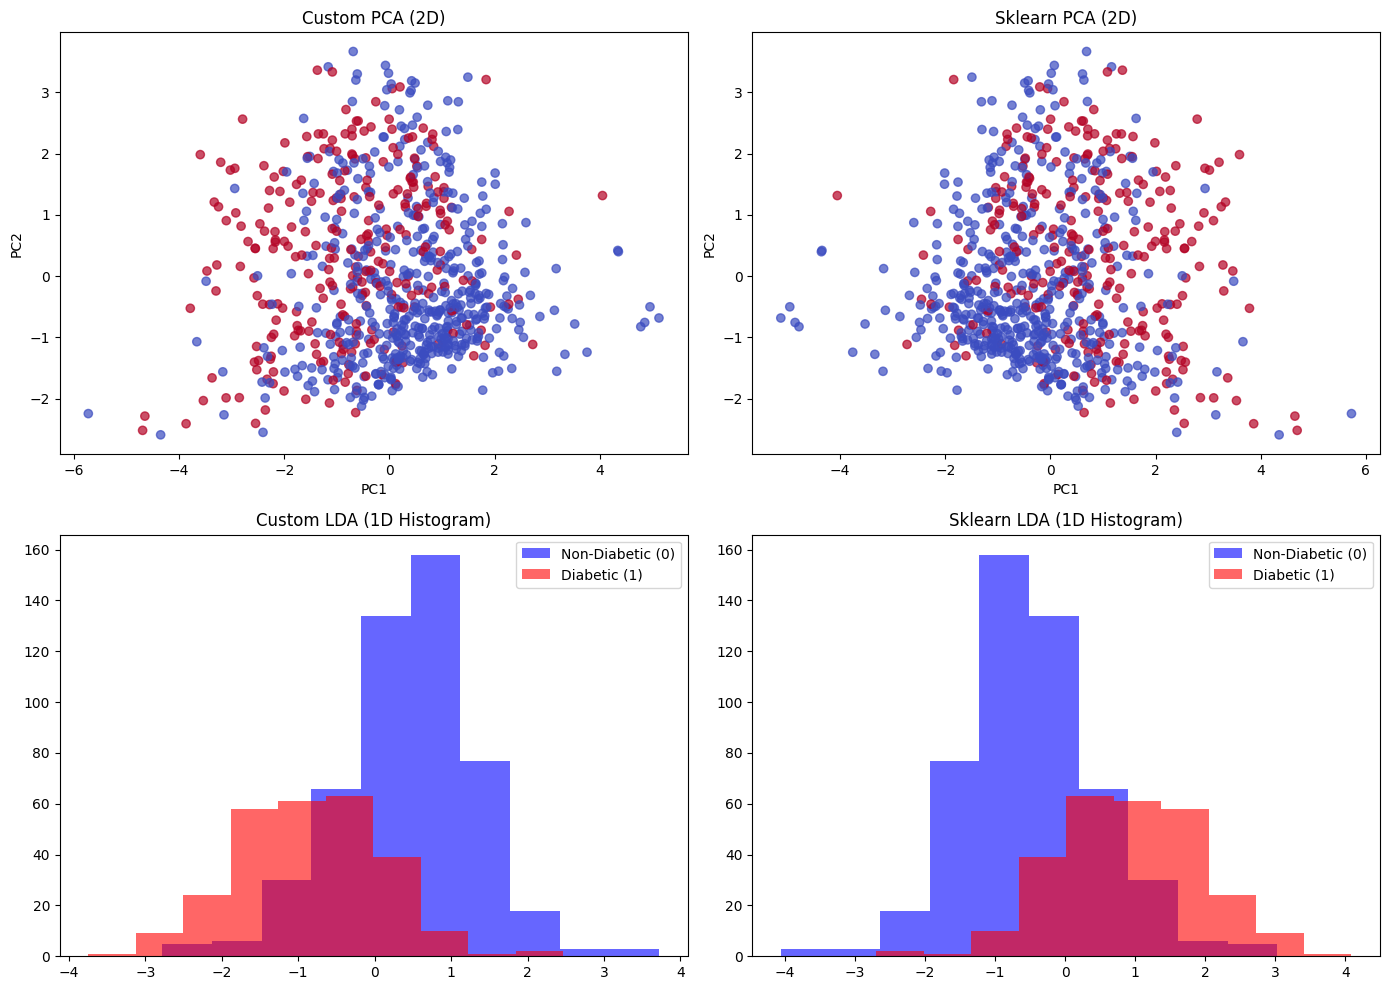

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Custom PCA
axes[0, 0].scatter(X_pca_custom[:, 0], X_pca_custom[:, 1], c=y, cmap='coolwarm', alpha=0.7)
axes[0, 0].set_title("Custom PCA (2D)")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")

# Sklearn PCA
axes[0, 1].scatter(X_pca_sk[:, 0], X_pca_sk[:, 1], c=y, cmap='coolwarm', alpha=0.7)
axes[0, 1].set_title("Sklearn PCA (2D)")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")

# Custom LDA
axes[1, 0].hist(X_lda_custom[y == 0], alpha=0.6, color='blue', label='Non-Diabetic (0)')
axes[1, 0].hist(X_lda_custom[y == 1], alpha=0.6, color='red', label='Diabetic (1)')
axes[1, 0].set_title("Custom LDA (1D Histogram)")
axes[1, 0].legend()

# Sklearn LDA
axes[1, 1].hist(X_lda_sk[y == 0], alpha=0.6, color='blue', label='Non-Diabetic (0)')
axes[1, 1].hist(X_lda_sk[y == 1], alpha=0.6, color='red', label='Diabetic (1)')
axes[1, 1].set_title("Sklearn LDA (1D Histogram)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()